In [1]:
import numpy as np
from scipy import stats
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [6]:
Data = pd.read_csv(r"F:\NTI\Python Project\Netflix\netflix_movies.csv")
Data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [7]:
Data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


# Check null

In [5]:
Data.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# NO Duplicate Values

In [ ]:
Data.duplicated().sum()

np.int64(0)

# Handling Missing Values

In [5]:
text_cols = ['director','cast','country']
Data[text_cols] = Data[text_cols].fillna('Unknown')

temp_numbers = Data['duration'].astype(str).str.extract(r'(\d+)').astype(float)
movie_median = temp_numbers[Data['type'] == 'Movie'].median().iloc[0]
tv_median = temp_numbers[Data['type'] == 'TV Show'].median().iloc[0]

def format_duration(row):
    val = str(row['duration'])
    nums = re.findall(r'\d+', val)
    
    if not nums or pd.isna(row['duration']):
        if row['type'] == 'Movie':
            return movie_median
        else:
            return tv_median         
    else:
        return float(nums[0])

Data['duration_num'] = Data.apply(format_duration, axis=1)
def duration_type(row):
    if row['type'] == 'Movie':
        return 'min'
    else:
        return 'season'

Data['duration_type'] = Data.apply(duration_type, axis=1)

Data['rating'] = Data['rating'].fillna(Data['rating'].mode()[0])

Data['date_added'] = pd.to_datetime(Data['date_added'], errors='coerce')
Data['date_added'] = Data['date_added'].ffill()
Data.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,season
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1.0,season
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0,min
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0,min
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9.0,season
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0,min


In [5]:
print(Data.apply(lambda col: col.map(lambda x: type(x).__name__).value_counts()))

           show_id    type   title  director    cast  country  date_added  \
Timestamp      NaN     NaN     NaN       NaN     NaN      NaN      8807.0   
float          NaN     NaN     NaN       NaN     NaN      NaN         NaN   
int            NaN     NaN     NaN       NaN     NaN      NaN         NaN   
str         8807.0  8807.0  8807.0    8807.0  8807.0   8807.0         NaN   

           release_year  rating  duration  listed_in  description  \
Timestamp           NaN     NaN       NaN        NaN          NaN   
float               NaN     NaN       3.0        NaN          NaN   
int              8807.0     NaN       NaN        NaN          NaN   
str                 NaN  8807.0    8804.0     8807.0       8807.0   

           duration_num  duration_type  
Timestamp           NaN            NaN  
float            8807.0            NaN  
int                 NaN            NaN  
str                 NaN         8807.0  


In [13]:
Data['year_added'] = Data['date_added'].dt.year
Data['month_added'] = Data['date_added'].dt.month
Data.dtypes

show_id                     str
type                        str
title                       str
director                    str
cast                        str
country                     str
date_added       datetime64[us]
release_year              int64
rating                      str
duration                    str
listed_in                   str
description                 str
duration_num            float64
duration_type               str
year_added                int32
month_added               int32
dtype: object

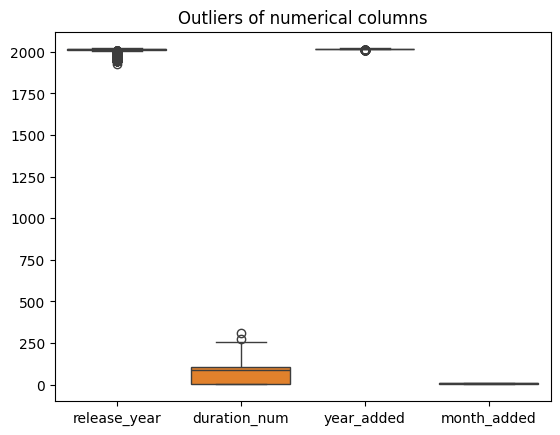

In [35]:
sns.boxplot(Data)
plt.xticks()
plt.title("Outliers of numerical columns")
plt.show()

# There are outliers in one column : duration_num

In [ ]:
z_scores = stats.zscore(Data['duration_num'])
outliers = Data[abs(z_scores) > 3.5]  
print(outliers['duration_num'])


717     273.0
2491    253.0
4253    312.0
Name: duration_num, dtype: float64


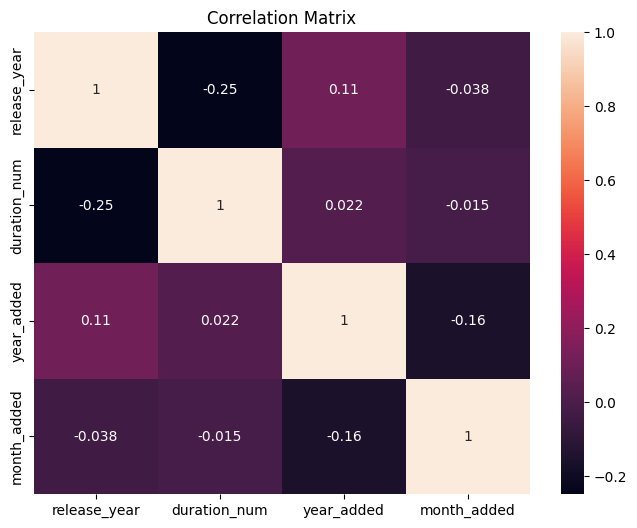

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(Data.corr(numeric_only=True), annot=True)
plt.title('Correlation Matrix')
plt.show()

# The newer the year, the more works tend to be relatively shorter, but the relationship is not very strong (correlation = -0.25)

# Movies duration average

In [14]:
movies_avg = Data[Data['type']=='Movie']['duration_num'].mean()
print("Average Movie Duration:", movies_avg)

Average Movie Duration: 99.57641494046648


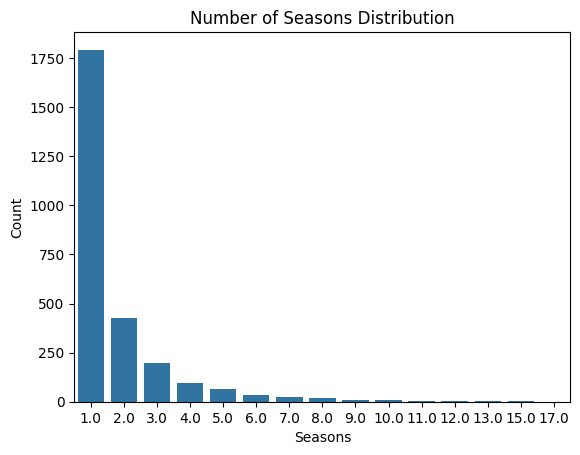

In [38]:
tv_data = Data[Data['type']=='TV Show']
sns.countplot(x='duration_num', data=tv_data)
plt.title('Number of Seasons Distribution')
plt.xlabel('Seasons')
plt.ylabel('Count')
plt.show()

# The most common tv shows with (1 season)

# The most common duration

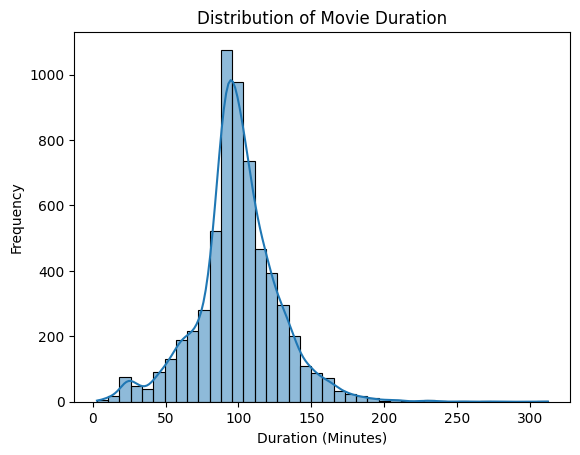

In [13]:
movie_data = Data[Data['type']=='Movie']
sns.histplot(movie_data['duration_num'], bins=40, kde=True)
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

# Top 10 Countries

<Axes: ylabel='country'>

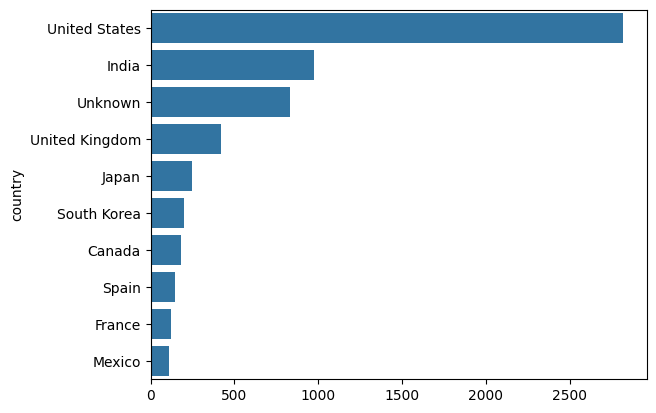

In [7]:
top_countries = Data['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)

# Years with Large Productivity

<Axes: xlabel='release_year'>

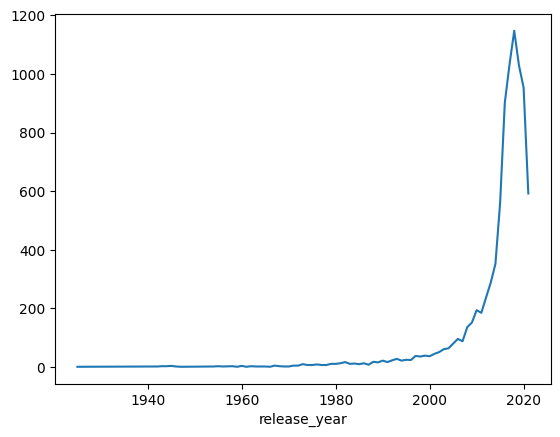

In [8]:
year_count = Data.groupby('release_year')['show_id'].count()
year_count.plot()

# Movies quantity in first 5 years

In [39]:
year_count = Data.groupby('release_year')['show_id'].count()
print(year_count.head())

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: show_id, dtype: int64


# Movies quantity in last 5 years

In [40]:
print(year_count.tail())

release_year
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: show_id, dtype: int64


# Movies quantity is almostly increased by Release year

# Top 5 Movies Recommendation

In [31]:
Data['content'] = Data['listed_in'] + " " + Data['description']
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(Data['content'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [32]:
def recommend(title, cosine_sim=cosine_sim):
    idx = Data[Data['title']==title].index[0]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    scores = scores[1:6]
    movie_indices = [i[0] for i in scores]
    return Data['title'].iloc[movie_indices]

In [34]:
recommend("Blood & Water")

108                Dive Club
4271              Lion Pride
4022             More to Say
222                Clickbait
4487    Accidentally in Love
Name: title, dtype: str